# Phase 2 - Data Preprocessing

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats.mstats import winsorize
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import statsmodels.stats as sm_stats
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate

plt.rcParams["font.family"] = "DejaVu Sans"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
def read_any(path):
    try:
        return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        return pd.read_csv(path, sep=";", engine="python", encoding="utf-8-sig")

patient = read_any("data/patient.csv")
station = read_any("data/station.csv")
observation = read_any("data/observation.csv")


## 2.1 Implementing Data Preprocessing

# A


In [4]:
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series >= lower) & (series <= upper)]


low_outlier_columns = ["SpO₂","PI","RR","PRV","Skin Temperature","Motion/Activity index","PVI","Hb level","SV","Blood Flow Index", "PPG waveform features","Signal Quality Index", "Respiratory effort"]
for column in low_outlier_columns:
    data = observation[column]
    data_without_outliers = remove_outliers_iqr(data)


def removing_outliers_low_percentatge(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        if col in cleaned_df.columns:
            Q1 = cleaned_df[col].quantile(0.25)
            Q3 = cleaned_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            before = len(cleaned_df)
            cleaned_df = cleaned_df[(cleaned_df[col] >= lower) & (cleaned_df[col] <= upper)]
            after = len(cleaned_df)

    return cleaned_df

In [5]:
observation_clean = removing_outliers_low_percentatge(observation, low_outlier_columns)

In [6]:
observation_clean.shape

(11118, 23)

The cleaned dataset was divided into a training, validating and testing set using an 60/20/20 ratio. We do this separation in order to compare models with the validation part in section 3. Test set will be only used to evaluate final performance of our best model, and not to compare models.
The target variable is oximetry, representing a binary classification problem (critical vs. normal state).
Stratified sampling was applied to preserve the class balance between both sets.

In [7]:
X = observation_clean.drop(columns=['oximetry'])
y = observation_clean['oximetry']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=11, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=11, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (6670, 22)
Validation set: (2224, 22)
Test set: (2224, 22)


# B

- The dataset observation_clean contains 23 numerical attributes and 11,118 records.
- An initial inspection using .info() and .isna() confirms that there are no missing values in any of the columns.
- All features are stored as float64, making the dataset already suitable for machine learning algorithms
- **(To be eliminated) Three columns: SpO₂ (is directly related to the target variable and could cause data leakage), latitude, and longitude (contain location metadata irrelevant for the classification task) were dropped from the predictors**

In [8]:
observation_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11118 entries, 0 to 12045
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   11118 non-null  float64
 1   HR                     11118 non-null  float64
 2   PI                     11118 non-null  float64
 3   RR                     11118 non-null  float64
 4   EtCO₂                  11118 non-null  float64
 5   FiO₂                   11118 non-null  float64
 6   PRV                    11118 non-null  float64
 7   BP                     11118 non-null  float64
 8   Skin Temperature       11118 non-null  float64
 9   Motion/Activity index  11118 non-null  float64
 10  PVI                    11118 non-null  float64
 11  Hb level               11118 non-null  float64
 12  SV                     11118 non-null  float64
 13  CO                     11118 non-null  float64
 14  Blood Flow Index       11118 non-null  float64
 15  PPG wav

In [9]:
display(observation_clean.isna().sum().sort_values(ascending=False))

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64

In [10]:
# target = "oximetry"

# drop_cols = ["SpO₂", "latitude", "longitude"]

# X = observation_clean.drop(columns=[c for c in drop_cols if c in observation_clean.columns])
# y = observation_clean[target].astype(int)

# print("Feature matrix shape:", X.shape)
# print("Target vector shape:", y.shape)

In [11]:
print(X.isna().sum().sum()) 

0


In [12]:
print("Final numeric dataset shape:", X.shape)

Final numeric dataset shape: (11118, 22)


# C

Before doing any preprocessing, we want to look at our target variable to see its distribution. We want to see if we have imbalance on our target variable. This is useful information for us right now because we will use some basic models to test preprocessing techniques.

In [17]:
print(observation_clean['oximetry'].value_counts())

oximetry
1.0    6608
0.0    4510
Name: count, dtype: int64


We can see that aproximately 60% of our data belongs to class1 (oximetry 1) and 40% to class 2 (oximetry 0). This is not an extreme case, so we won't apply any sampling technique, but we'll take into account the situation when we adjust our models and select out metriques.

To prepare the data for machine learning, several feature transformation techniques were applied and evaluated.

**Two main categories of preprocessing were tested together with a Logistic Regression classifier:**
- Scaling methods: StandardScaler and MinMaxScaler
- Transformers: PowerTransformer (Yeo–Johnson) and PCA (Principal Component Analysis)

**Scaling Techniques**
- Both scalers achieved nearly identical results, with accuracy around 0.85, precision around 0.84–0.85, and f1-score around 0.85.
This indicates that the model performs similarly under both scaling methods and that the features are relatively well-behaved numerically.

**Transformation Techniques**
- The PowerTransformer achieved slightly better overall performance (accuracy = 0.85) compared to PCA (accuracy = 0.84).
This suggests that normalizing skewed distributions was more effective than dimensionality reduction in this dataset.

In [ ]:
# pipe_std = Pipeline([
#     ('scale', StandardScaler()),
#     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
# ])

# pipe_minmax = Pipeline([
#     ('scale', MinMaxScaler()),
#     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
# ])
 
# pipe_std.fit(X_train, y_train)
# pipe_minmax.fit(X_train, y_train)

# y_pred_std = pipe_std.predict(X_test)
# y_pred_minmax = pipe_minmax.predict(X_test)

# print("=== StandardScaler ===")
# print(classification_report(y_test, y_pred_std))

# print("=== MinMaxScaler ===")
# print(classification_report(y_test, y_pred_minmax))

In [ ]:
# pipe_power = Pipeline([
#     ('transform', PowerTransformer(method='yeo-johnson')),
#     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
# ])


# pipe_pca = Pipeline([
#     ('scale', StandardScaler()),   
#     ('pca', PCA(n_components=5)),  
#     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
# ])

# pipe_power.fit(X_train, y_train)
# y_pred_power = pipe_power.predict(X_test)

# pipe_pca.fit(X_train, y_train)
# y_pred_pca = pipe_pca.predict(X_test)

# print("=== PowerTransformer ===")
# print(classification_report(y_test, y_pred_power))

# print("=== PCA Transformer ===")
# print(classification_report(y_test, y_pred_pca))

In [20]:
scalers = {
    "none": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
}

transformers = {
    "none": None,
    "power": PowerTransformer(method='yeo-johnson'),
    "quantile": QuantileTransformer(output_distribution='normal', random_state=11),
}

reducers = {
    "none": None,
    "pca": PCA(n_components=0.95, random_state=11),
    "lda": LinearDiscriminantAnalysis(n_components=1),
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']

In [21]:
for s_name, scaler in scalers.items():
    for t_name, transformer in transformers.items():
        for r_name, reducer in reducers.items():
            steps = []
            if scaler is not None:
                steps.append(("scaler", scaler))
            if transformer is not None:
                steps.append(("transformer", transformer))
            if reducer is not None:
                steps.append(("reducer", reducer))
            steps.append(("clf", LogisticRegression(max_iter=1000, random_state=11)))
            
            pipe = Pipeline(steps)
            combo_name = f"{s_name} + {t_name} + {r_name}"
            
            scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
            mean_scores = {metric: np.mean(scores[f"test_{metric}"]) for metric in scoring}
            
            results.append({
                "combination": combo_name,
                **mean_scores
            })
            print(f"Done: {combo_name} | F1_macro: {mean_scores['f1_macro']:.4f}")

Done: none + none + none | F1_macro: 0.8374
Done: none + none + pca | F1_macro: 0.3728
Done: none + none + lda | F1_macro: 0.8429
Done: none + power + none | F1_macro: 0.8451
Done: none + power + pca | F1_macro: 0.8474
Done: none + power + lda | F1_macro: 0.8436
Done: none + quantile + none | F1_macro: 0.8385
Done: none + quantile + pca | F1_macro: 0.8379
Done: none + quantile + lda | F1_macro: 0.8402
Done: standard + none + none | F1_macro: 0.8442
Done: standard + none + pca | F1_macro: 0.8450
Done: standard + none + lda | F1_macro: 0.8429
Done: standard + power + none | F1_macro: 0.8458
Done: standard + power + pca | F1_macro: 0.8484
Done: standard + power + lda | F1_macro: 0.8456
Done: standard + quantile + none | F1_macro: 0.8385
Done: standard + quantile + pca | F1_macro: 0.8379
Done: standard + quantile + lda | F1_macro: 0.8402
Done: minmax + none + none | F1_macro: 0.8444
Done: minmax + none + pca | F1_macro: 0.8403
Done: minmax + none + lda | F1_macro: 0.8429
Done: minmax + pow

In [22]:
results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

print("\nTop 3 combinations by F1 score:")
print(results_df.head(3))


Top 3 combinations by F1 score:
              combination  accuracy  precision_macro  recall_macro  f1_macro   roc_auc
0  standard + power + pca  0.854273         0.849781      0.847259  0.848382  0.921159
1    minmax + power + pca  0.853523         0.849189      0.846101  0.847481  0.920927
2      none + power + pca  0.853373         0.848878      0.846268  0.847427  0.921062


In [23]:
pipe_final = Pipeline([
    ('scale', StandardScaler()),
    ('transform', PowerTransformer()),
    ('reduce', PCA(n_components=0.95)),
])

X_train_prep = pipe_final.fit_transform(X_train)

In [29]:
X_train_prep_df = pd.DataFrame(X_train_prep)
print(X_train_prep_df.describe().T)
print(X_train_prep_df.info())

     count          mean       std       min       25%       50%       75%       max
0   6670.0 -2.130563e-18  1.408590 -3.827412 -1.035184 -0.214539  0.940256  4.879897
1   6670.0  3.195844e-18  1.281172 -3.784987 -0.804245 -0.092534  0.694649  3.945171
2   6670.0  7.456970e-18  1.166512 -3.657394 -0.857098 -0.089462  0.852105  4.216672
3   6670.0 -5.326407e-19  1.075354 -4.450577 -0.705839  0.024391  0.735240  3.830367
4   6670.0  1.491394e-17  1.045839 -3.167337 -0.755075 -0.026661  0.735894  3.474783
5   6670.0 -1.491394e-17  1.035009 -3.763532 -0.704400 -0.009304  0.696348  3.843617
6   6670.0  0.000000e+00  1.023682 -3.492812 -0.702432 -0.000391  0.680226  3.402216
7   6670.0 -1.544658e-17  1.014726 -3.406466 -0.712925  0.002119  0.693195  3.539407
8   6670.0 -1.917507e-17  1.011094 -3.482878 -0.691014 -0.011098  0.690373  3.448846
9   6670.0 -2.876260e-17  1.008408 -3.834205 -0.686722  0.001920  0.673552  4.093349
10  6670.0 -1.491394e-17  1.004665 -3.873908 -0.658637  0.012014 

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: title={'center': '5'}>,
        <Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>],
       [<Axes: title={'center': '8'}>, <Axes: title={'center': '9'}>,
        <Axes: title={'center': '10'}>, <Axes: title={'center': '11'}>],
       [<Axes: title={'center': '12'}>, <Axes: title={'center': '13'}>,
        <Axes: title={'center': '14'}>, <Axes: title={'center': '15'}>],
       [<Axes: title={'center': '16'}>, <Axes: title={'center': '17'}>,
        <Axes: title={'center': '18'}>, <Axes: >]], dtype=object)

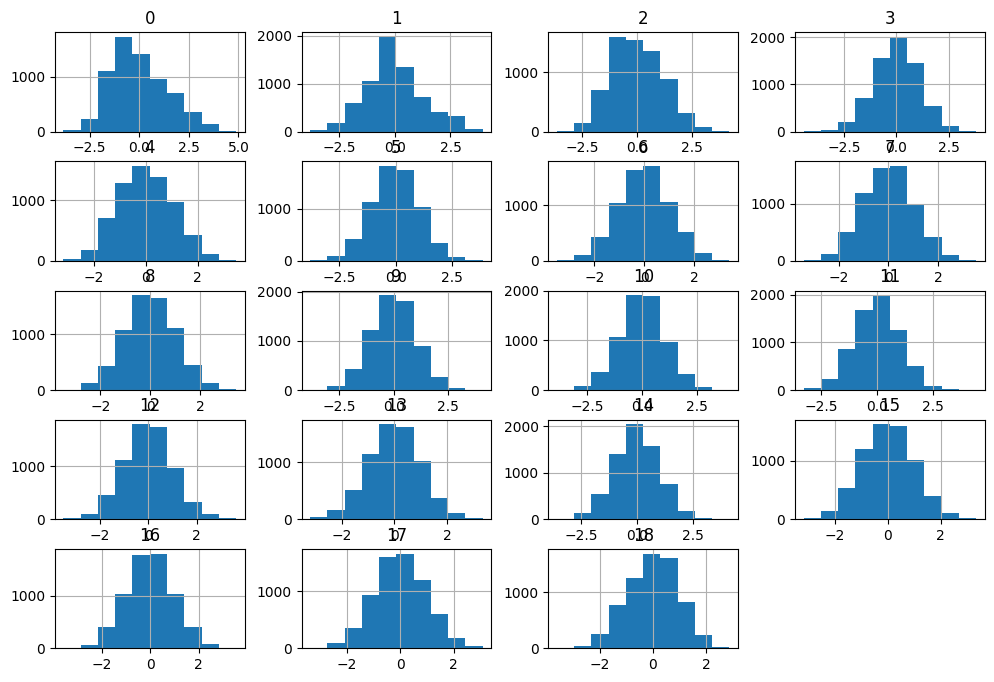

In [30]:
X_train_prep_df.hist(figsize=(12,8))

array([[<Axes: xlabel='0', ylabel='0'>, <Axes: xlabel='1', ylabel='0'>,
        <Axes: xlabel='2', ylabel='0'>, <Axes: xlabel='3', ylabel='0'>,
        <Axes: xlabel='4', ylabel='0'>, <Axes: xlabel='5', ylabel='0'>,
        <Axes: xlabel='6', ylabel='0'>, <Axes: xlabel='7', ylabel='0'>,
        <Axes: xlabel='8', ylabel='0'>, <Axes: xlabel='9', ylabel='0'>,
        <Axes: xlabel='10', ylabel='0'>, <Axes: xlabel='11', ylabel='0'>,
        <Axes: xlabel='12', ylabel='0'>, <Axes: xlabel='13', ylabel='0'>,
        <Axes: xlabel='14', ylabel='0'>, <Axes: xlabel='15', ylabel='0'>,
        <Axes: xlabel='16', ylabel='0'>, <Axes: xlabel='17', ylabel='0'>,
        <Axes: xlabel='18', ylabel='0'>],
       [<Axes: xlabel='0', ylabel='1'>, <Axes: xlabel='1', ylabel='1'>,
        <Axes: xlabel='2', ylabel='1'>, <Axes: xlabel='3', ylabel='1'>,
        <Axes: xlabel='4', ylabel='1'>, <Axes: xlabel='5', ylabel='1'>,
        <Axes: xlabel='6', ylabel='1'>, <Axes: xlabel='7', ylabel='1'>,
        <Axes:

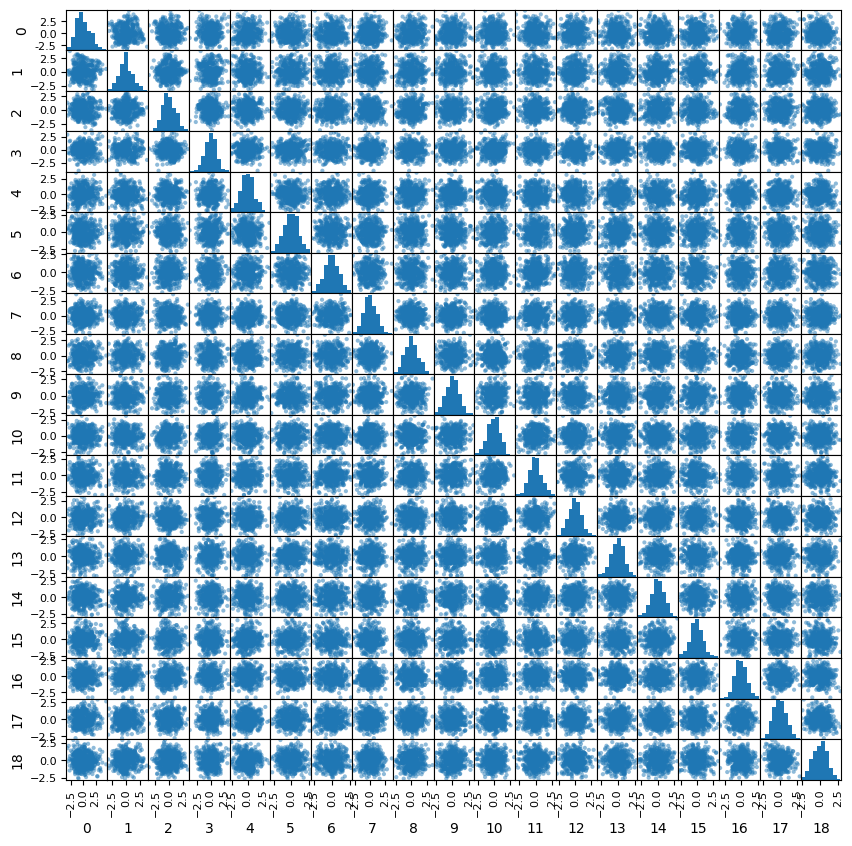

In [31]:
pd.plotting.scatter_matrix(X_train_prep_df.sample(500), figsize=(10,10))

# D

**Data Selection and Structure**

The analysis focused on the observation_clean dataset, which contained all relevant physiological attributes in numeric form.
Files (station, patient) were excluded from the preprocessing pipeline because they contained data not essential for modeling oxygen saturation states.

**Data Cleaning**

An inspection with .info() and .isna() confirmed that the dataset had no missing values and all columns were of type float64.
This eliminated the need for imputation or categorical encoding.

**Feature Preparation**

The target variable was defined as oximetry, representing a binary classification problem. SpO₂ (directly related to the target and would cause data leakage), latitude and longitude (provide only metadata without physiological meaning)
were removed.

**Scaling and Transformation**

Four transformation approaches were tested:
- StandardScaler – normalization to zero mean and unit variance.
- MinMaxScaler – scaling to a [0, 1] range.
- PowerTransformer (Yeo–Johnson) - was chosen to adjust for skewed distributions of numerical attributes, which allows linear models to better capture relationships in the data and reduce the impact of extreme values.
- Principal Component Analysis - was used as a dimensionality reduction. It simplifies data by removing redundancy between correlated attributes. It creates a smaller dataset that still contains the essential information.